In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP

from src.datasets import QM9Dataset
from scripts.materials_project.euclidean_evaluation_pipeline import build_invariant_matrix, _compute_ncut
from src.helper_functions import create_chemiscope_viewer

In [3]:
qm9 = QM9Dataset(limit=5000, stratify_by=['num_atoms', 'gap'], sampling_strategy="stratified", add_soap=True)
df = qm9.load()
soap_matrix = np.array(df['soap_embedding'].to_list())
umap = UMAP(n_components=4, random_state=42)
soap_umap_matrix = umap.fit_transform(soap_matrix)

2026-04-08 11:29:48.939 | INFO     | src.datasets:load:485 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-08 11:29:49.227 | INFO     | src.datasets:_sample_qm9_df:677 - QM9 sampling complete: strategy=stratified, requested_limit=5500, returned_rows=5500.
2026-04-08 11:29:49.228 | INFO     | src.datasets:_add_requested_descriptors:125 - Applying requested QM9 descriptors to sampled dataframe (rows=5500).
2026-04-08 11:29:49.229 | INFO     | src.features:compute_soap:162 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-04-08 11:30:34.799 | SUCCESS  | src.datasets:add_soap:831 - Added SOAP embeddings.
2026-04-08 11:30:34.803 | INFO     | src.datasets:_add_requested_descriptors:148 - Added descriptor column(s): ['soap_embedding']
2026-04-08 11:30:34.806 | INFO     | src.datasets:_drop_rows_with_null_required_descriptors:570 - Dropped QM9 rows with null/empty descriptor vectors: dropped=23, remaining=5477, descriptor_cols=['soap_embedding'].
2026-04-08 1

Evaluating KMeans for different cluster counts: 100%|██████████| 18/18 [00:09<00:00,  1.99it/s]


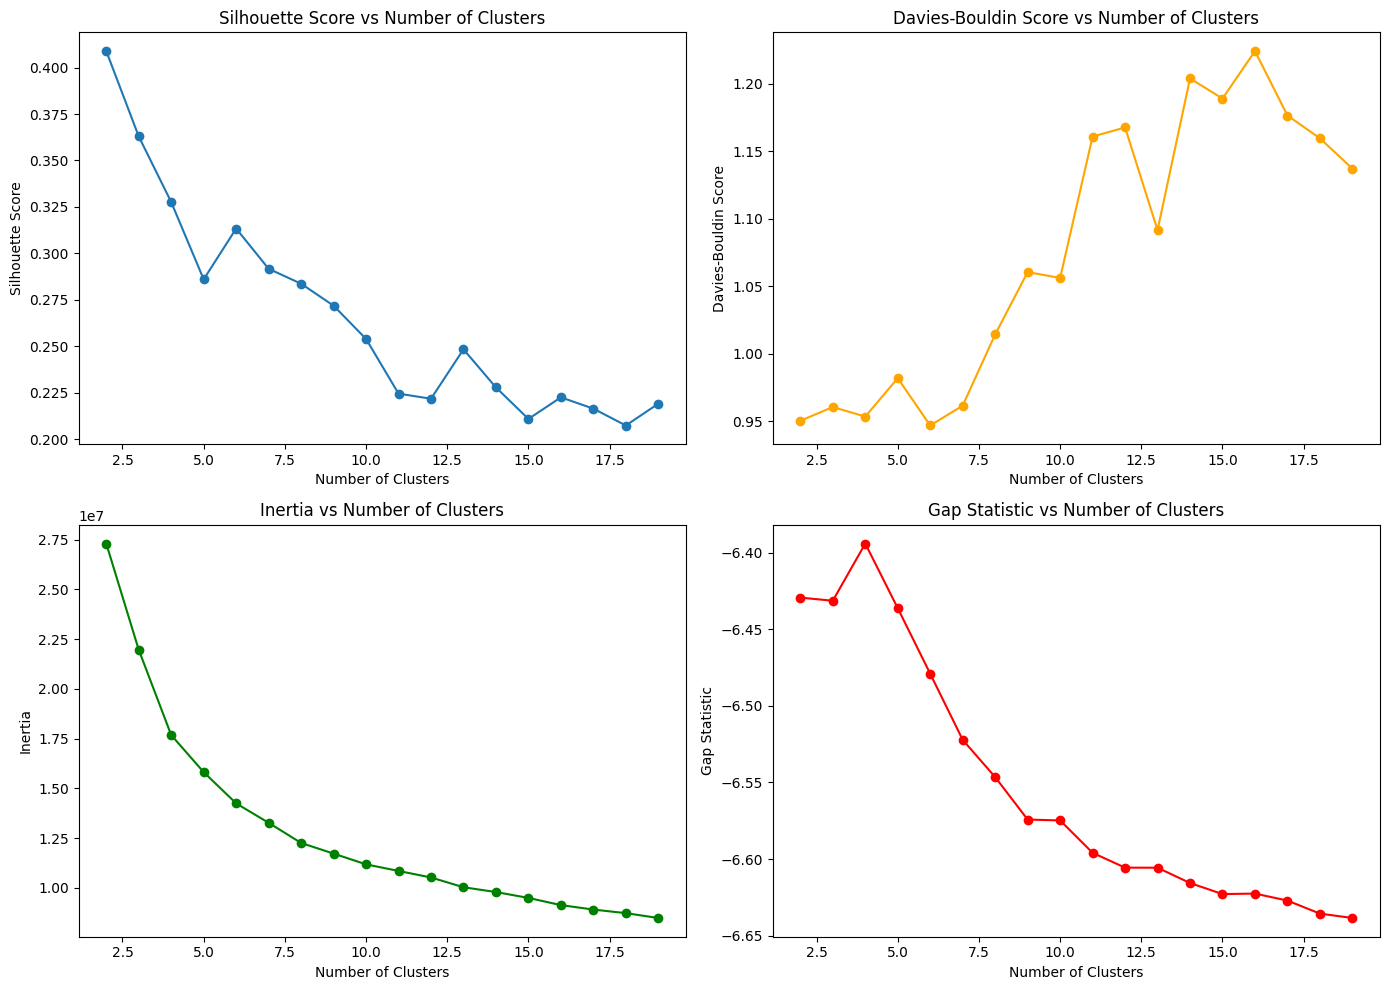

In [4]:
# Helper function to compute the Gap Statistic
def calculate_gap_statistic(data, k, actual_inertia, n_refs=5):
    # Get the bounding box of the data
    mins = np.min(data, axis=0)
    maxs = np.max(data, axis=0)
    shape = data.shape
    
    ref_inertias = []
    # Generate random reference datasets and find their inertias
    for _ in range(n_refs):
        ref_data = np.random.uniform(mins, maxs, shape)
        km = KMeans(n_clusters=k, random_state=42, n_init='auto')
        km.fit(ref_data)
        ref_inertias.append(km.inertia_)
        
    # Gap = expected log(inertia) of random data - log(inertia) of actual data
    gap = np.mean(np.log(ref_inertias)) - np.log(actual_inertia)
    return gap

sil_scores = []
db_scores = []
inertia_scores = []
gap_scores = []

k_max = 20
k_range = range(2, k_max)

for i in tqdm(k_range, desc="Evaluating KMeans for different cluster counts"):
    # Fit KMeans
    kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(soap_matrix)
    
    # Calculate Standard Metrics
    sil = silhouette_score(soap_umap_matrix, labels)
    db = davies_bouldin_score(soap_umap_matrix, labels)
    actual_inertia = kmeans.inertia_
    
    # Calculate Gap Statistic using the actual inertia we just found
    gap = calculate_gap_statistic(soap_umap_matrix, i, actual_inertia, n_refs=5)
    
    # Append to lists
    sil_scores.append(sil)
    db_scores.append(db)
    inertia_scores.append(actual_inertia)
    gap_scores.append(gap)

# Plotting
plt.figure(figsize=(14, 10))

# 1. Silhouette Score (Higher is better)
plt.subplot(2, 2, 1)
plt.plot(k_range, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

# 2. Davies-Bouldin Score (Lower is better)
plt.subplot(2, 2, 2)
plt.plot(k_range, db_scores, marker='o', color='orange')
plt.title('Davies-Bouldin Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Score')

# 3. Inertia (Elbow Method - look for the "kink")
plt.subplot(2, 2, 3)
plt.plot(k_range, inertia_scores, marker='o', color='green')
plt.title('Inertia vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

# 4. Gap Statistic (Higher is better, or first local maximum)
plt.subplot(2, 2, 4)
plt.plot(k_range, gap_scores, marker='o', color='red')
plt.title('Gap Statistic vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Gap Statistic')

plt.tight_layout()
plt.show()

In [5]:
best_k = 6 # 9

labels = KMeans(n_clusters=best_k, random_state=42, n_init='auto').fit_predict(soap_umap_matrix)
df = df.with_columns(pl.Series("cluster_label", labels))

sil = silhouette_score(soap_umap_matrix, labels)
db = davies_bouldin_score(soap_umap_matrix, labels)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")

Silhouette Score: 0.3580
Davies-Bouldin Score: 0.8979


In [6]:
reducer = 'UMAP'
create_chemiscope_viewer(df, soap_matrix, labels=labels, reduction_method=reducer)

Running UMAP dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_UMAP_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_UMAP_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


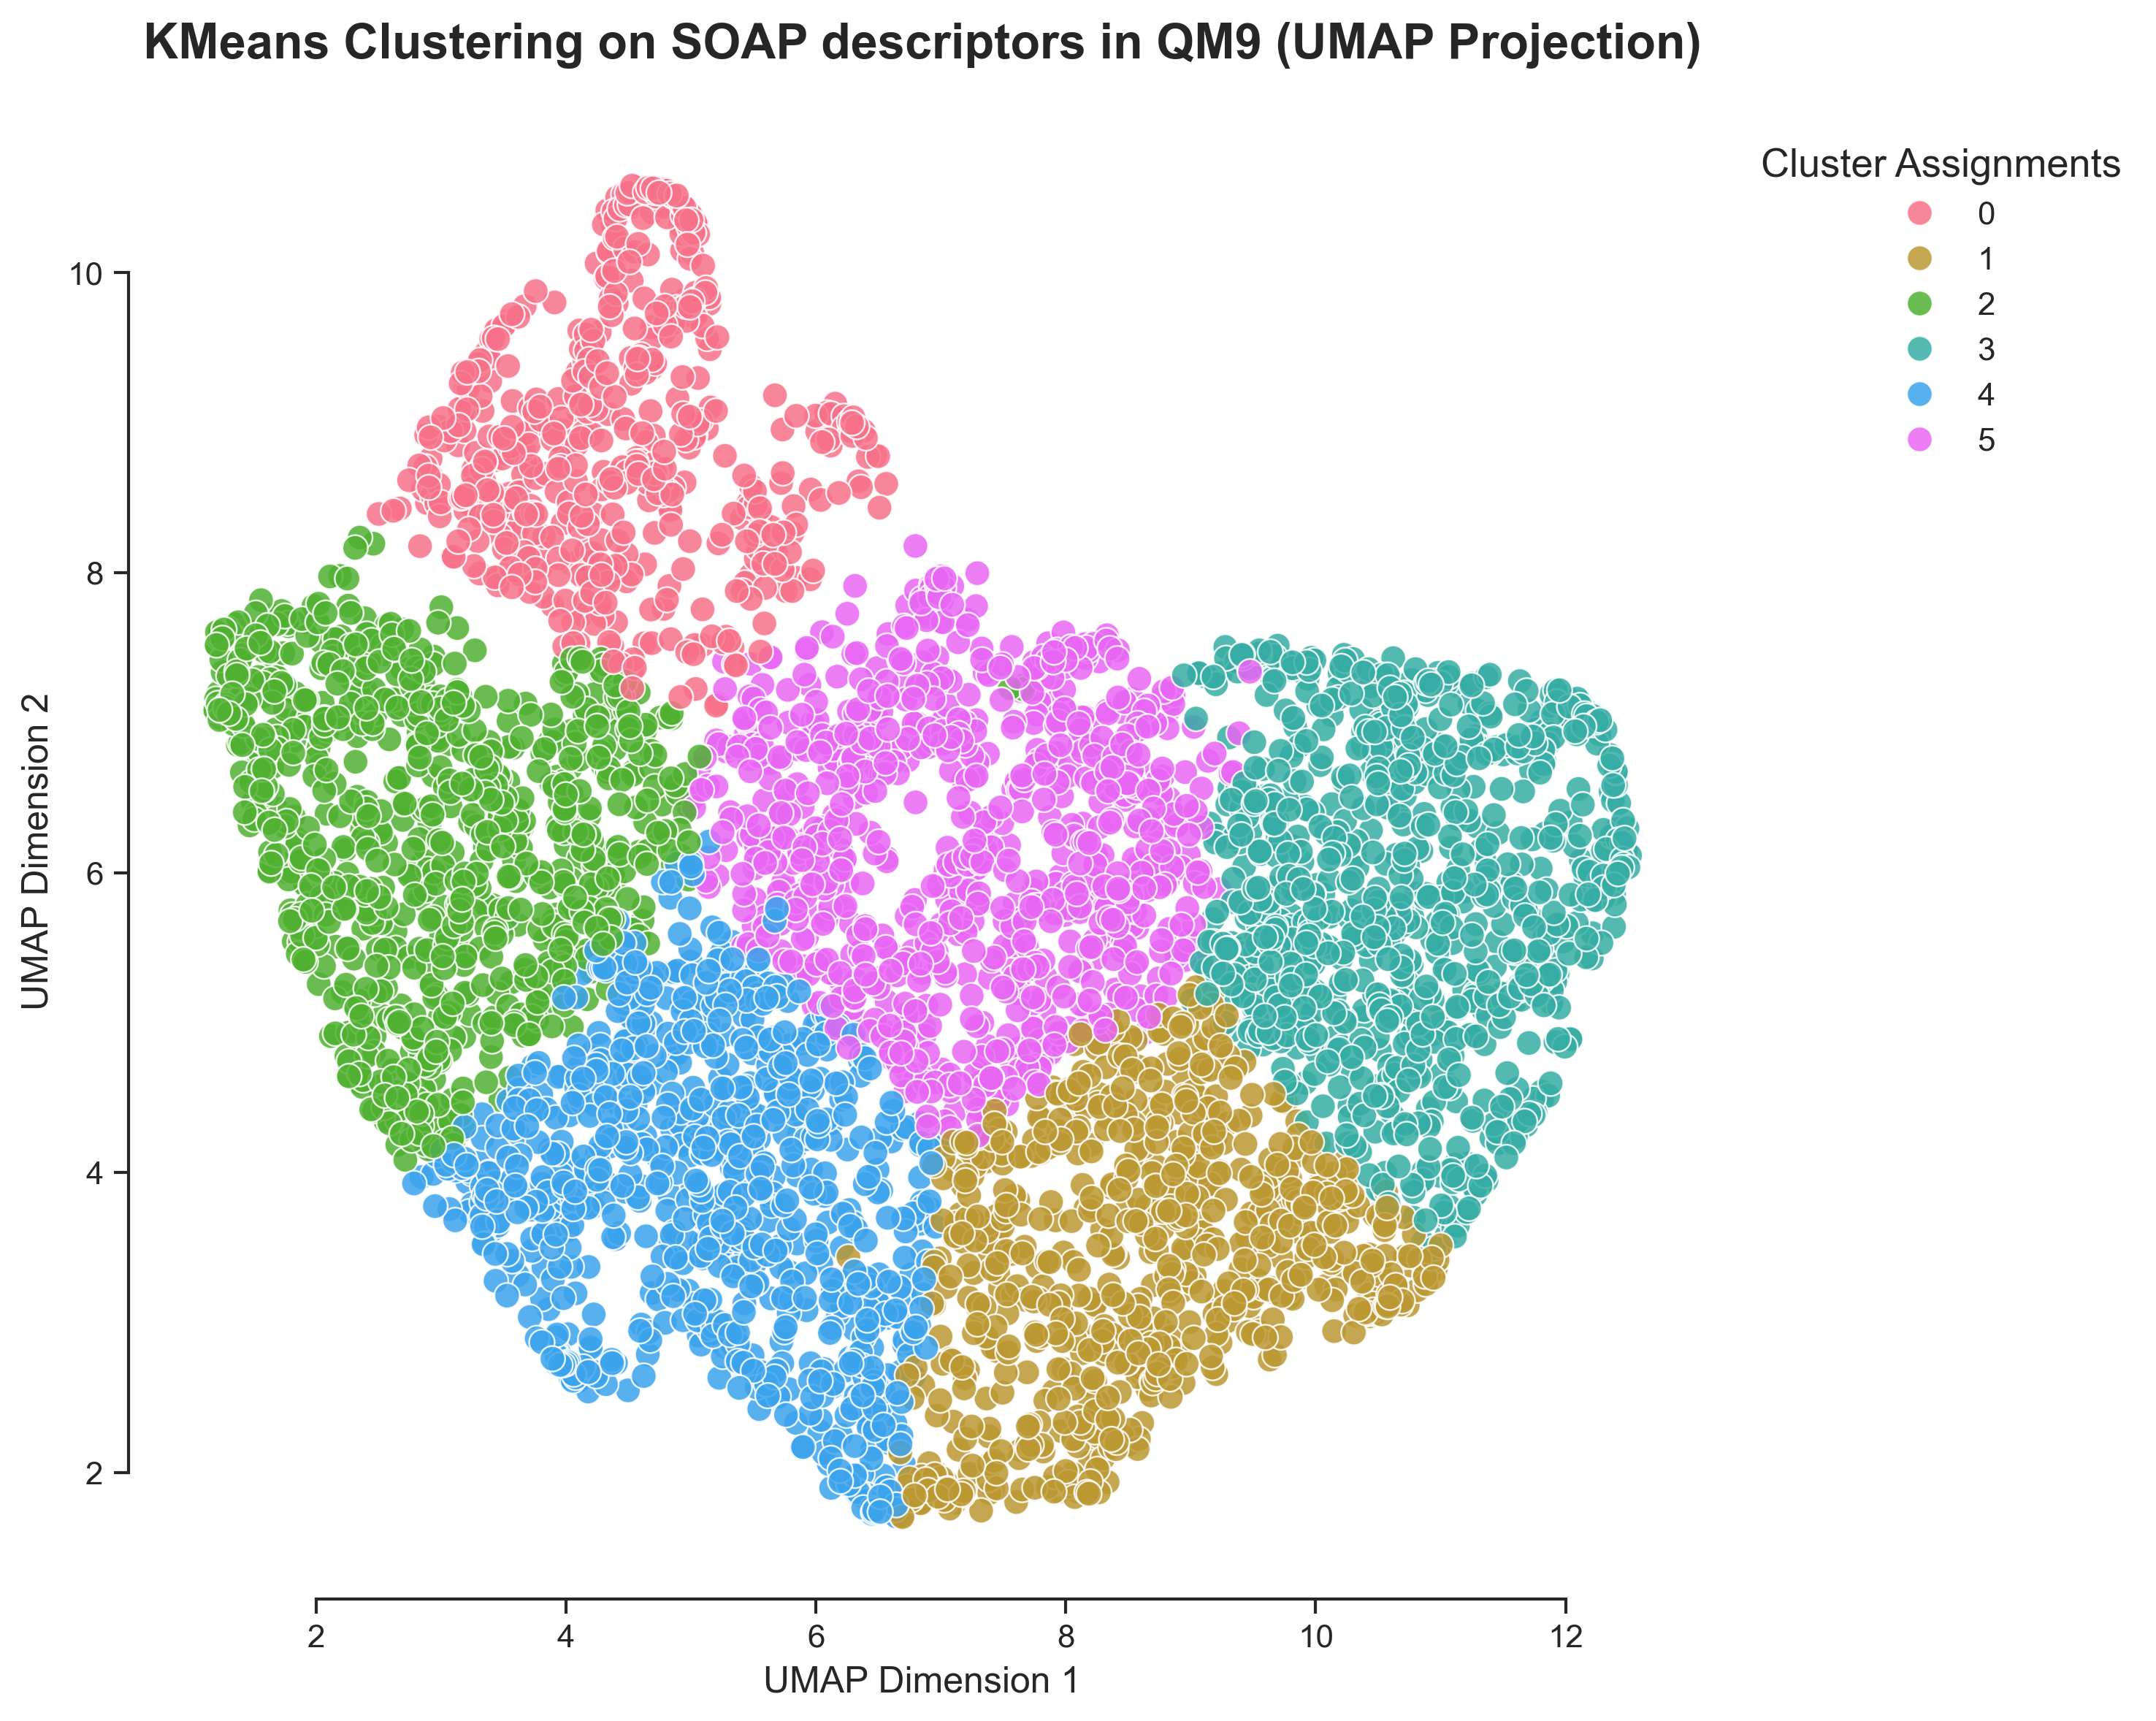

In [9]:
umap = UMAP(n_components=2, random_state=42)
umap_embedding = umap.fit_transform(soap_matrix)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

labels = np.array(labels)
unique_labels = np.unique(labels)
n_clusters = len([l for l in unique_labels if l != -1])

noise_mask = (labels == -1)
if noise_mask.any():
    ax.scatter(
        umap_embedding[noise_mask, 0], 
        umap_embedding[noise_mask, 1], 
        c='#B0B0B0',     
        s=15,            
        alpha=0.4,         
        label='Noise (-1)',
        edgecolors='none'
    )

cluster_mask = (labels != -1)
if cluster_mask.any():
    palette = sns.color_palette("husl", n_clusters)
    
    sns.scatterplot(
        x=umap_embedding[cluster_mask, 0], 
        y=umap_embedding[cluster_mask, 1], 
        hue=labels[cluster_mask], 
        palette=palette,
        s=70,              
        alpha=0.85,        
        edgecolor='white', 
        linewidth=0.6,
        ax=ax,
        legend='full'
    )

ax.set_title('KMeans Clustering on SOAP descriptors in QM9 (UMAP Projection)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('UMAP Dimension 1', fontsize=12, fontweight='medium')
ax.set_ylabel('UMAP Dimension 2', fontsize=12, fontweight='medium')

sns.despine(trim=True, offset=5)

# 7. Legend Formatting
# Move legend outside the plot, remove its ugly box
ax.legend(title="Cluster Assignments", 
          bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          frameon=False, 
          title_fontsize='13')

plt.tight_layout()

plt.savefig("figures/qm9/clustering/kmeans/soap_reduced/kmeans_soap_umap_clusters.png", dpi=300, bbox_inches='tight')

plt.show()

In [12]:
def average_numeric_by_cluster(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups a Polars DataFrame by 'cluster_label' and returns 
    the mean of all numeric columns along with the count of elements.
    """
    return (
        df.group_by("cluster_label")
        .agg(
            pl.len().alias("count"),  # Adds the number of elements per cluster
            pl.col(pl.NUMERIC_DTYPES).mean()
        )
        .sort("cluster_label")
    )


print("KMeans")
cluster_averages = average_numeric_by_cluster(df)
with pl.Config(set_tbl_cols=-1, set_tbl_width_chars=1000, set_tbl_rows=-1):
    print(cluster_averages)


KMeans
shape: (6, 55)
┌───────────────┬───────┬───────────┬────────────┬───────────┬───────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬──────────┬───────────┬───────────┬──────────┬──────────┬─────────────┬──────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────┬────────────┬────────────┬────────────┬────────────┬──────────┬──────────┬──────────┐
│ cluster_label ┆ count ┆ num_atoms ┆ mol_weight ┆ logp      ┆ tpsa      ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_rings ┆ num_aromatic_rings ┆ coordination 

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_70564/2492321108.py:10: DeprecationWarning: `NUMERIC_DTYPES` was deprecated in version 1.0.0. Define your own data type groups or use the `polars.selectors` module for selecting columns of a certain data type.
  pl.col(pl.NUMERIC_DTYPES).mean()
